In [14]:
import os
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

DATA_DIR = Path('../data/raw/PlantVillage')

classes = sorted([
    d.name for d in DATA_DIR.iterdir()
])

print(f"Classes:{classes}")
print(f"{type(classes)}")
print(f"torch_version:{torch.__version__}")

Classes:['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
<class 'list'>
torch_version:2.11.0+cpu


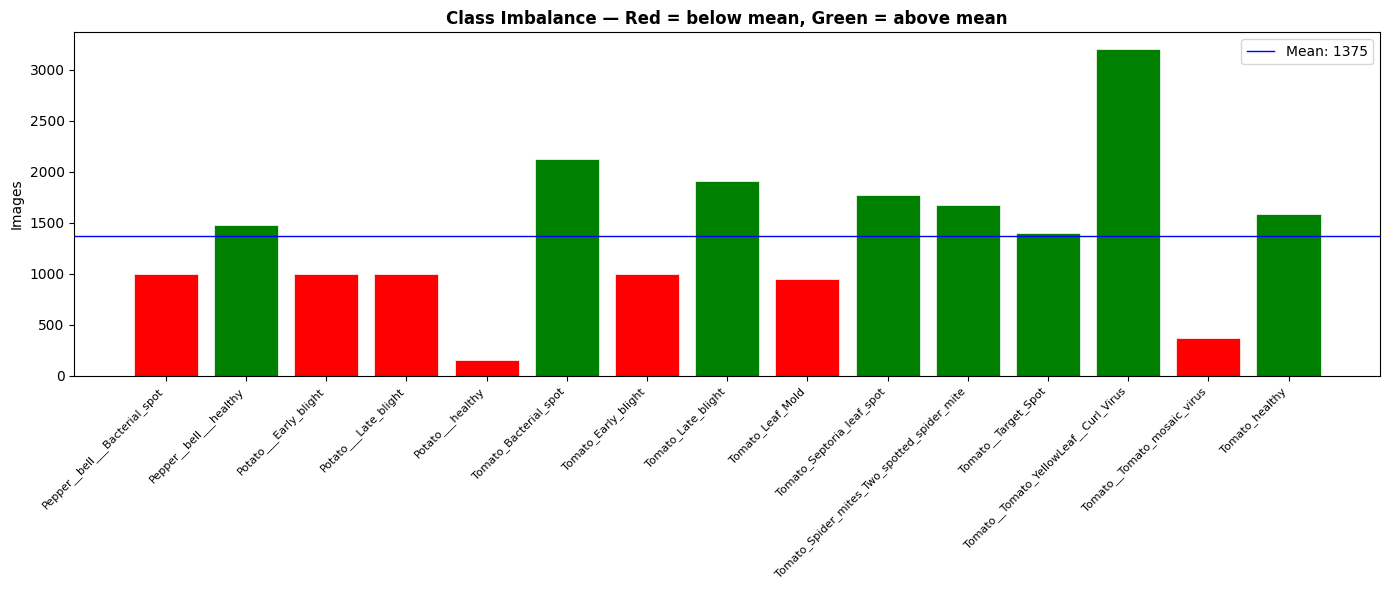

In [26]:
class_count = {}

for cls in classes:
    imgs = list((DATA_DIR / cls).glob('*.jpg'))
    class_count[cls] = len(imgs)

names = list(class_count.keys())
counts = list(class_count.values())

mean_count = sum(counts) / len(counts)
bar_colors = ['red' if c < mean_count else 'green' for c in counts]

fig, ax = plt.subplots(figsize=(14,6))
ax.bar(range(len(names)), counts, color = bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, fontsize=8, ha='right')
ax.axhline(y=mean_count, color='blue', linestyle='-', linewidth=1, label=f'Mean: {int(mean_count)}')
ax.set_ylabel('Images')
ax.set_title('Class Imbalance — Red = below mean, Green = above mean', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150)
plt.show()

In [33]:
total_images = sum(counts)
# print(total_images)
class_weights = {cls: total_images/(len(classes)* count)
                 for cls, count in class_count.items()}
print("Class weights (higher = model focuses more on this class):\n")
for cls, weight in sorted(class_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cls}: {weight:.4f}")

weight_tensor = torch.tensor([class_weights[cls] for cls in classes], dtype=torch.float)
print(f"\n Weights tensor shape : {weight_tensor.shape}")
print(weight_tensor)


Class weights (higher = model focuses more on this class):

  Potato___healthy: 9.0509
  Tomato__Tomato_mosaic_virus: 3.6883
  Tomato_Leaf_Mold: 1.4451
  Pepper__bell___Bacterial_spot: 1.3799
  Potato___Early_blight: 1.3757
  Potato___Late_blight: 1.3757
  Tomato_Early_blight: 1.3757
  Tomato__Target_Spot: 0.9799
  Pepper__bell___healthy: 0.9314
  Tomato_healthy: 0.8647
  Tomato_Spider_mites_Two_spotted_spider_mite: 0.8208
  Tomato_Septoria_leaf_spot: 0.7768
  Tomato_Late_blight: 0.7210
  Tomato_Bacterial_spot: 0.6468
  Tomato__Tomato_YellowLeaf__Curl_Virus: 0.4288

 Weights tensor shape : torch.Size([15])
tensor([1.3799, 0.9314, 1.3757, 1.3757, 9.0509, 0.6468, 1.3757, 0.7210, 1.4451,
        0.7768, 0.8208, 0.9799, 0.4288, 3.6883, 0.8647])


In [34]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transforms:")
print(train_transforms)
print("\nVal/Test transforms:")
print(val_transforms)

Train transforms:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.3)
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.1, 0.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [39]:
# Load full dataset with training transforms first
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)

print(f"Total images : {len(full_dataset)}")
print(f"Classes found: {len(full_dataset.classes)}")
print(f"Class to index: {full_dataset.class_to_idx}")

total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator= torch.Generator().manual_seed(42))

val_dataset.dataset.transform  = val_transforms
test_dataset.dataset.transform = val_transforms

print(f"\nTrain : {len(train_dataset)} images")
print(f"Val   : {len(val_dataset)} images")
print(f"Test  : {len(test_dataset)} images")

Total images : 20638
Classes found: 15
Class to index: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}

Train : 16510 images
Val   : 2063 images
Test  : 2065 images


In [41]:
BATCH_SIZE = 32
NUM_WORKERS =0

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS)

print(f"\nTrain : {len(train_loader)}")
print(f"Val   : {len(val_loader)}")
print(f"Test  : {len(test_loader)}")



Train : 516
Val   : 65
Test  : 65


In [42]:
print(f"\nTrain : {len(train_dataset)} images")
print(f"Val   : {len(val_dataset)} images")
print(f"Test  : {len(test_dataset)} images")

print(f"\nTrain : {len(train_loader)*32}")
print(f"Val   : {len(val_loader) *32}")
print(f"Test  : {len(test_loader) *32}")


Train : 16510 images
Val   : 2063 images
Test  : 2065 images

Train : 16512
Val   : 2080
Test  : 2080


In [46]:
images, labels = next(iter(train_loader))

print(f"Batch image shape : {images.shape}")   # should be [32, 3, 224, 224]
print(f"Batch label shape : {labels.shape}")   # should be [32]
print(f"Image dtype       : {images.dtype}")
print(f"Min pixel value   : {images.min():.4f}")
print(f"Max pixel value   : {images.max():.4f}")
print(f"Labels in batch   : {labels.tolist()}")

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])
Image dtype       : torch.float32
Min pixel value   : -2.1179
Max pixel value   : 2.4483
Labels in batch   : [1, 12, 11, 11, 6, 5, 12, 1, 1, 5, 14, 4, 12, 5, 7, 2, 6, 7, 3, 5, 5, 1, 7, 1, 12, 6, 7, 14, 1, 14, 3, 5]


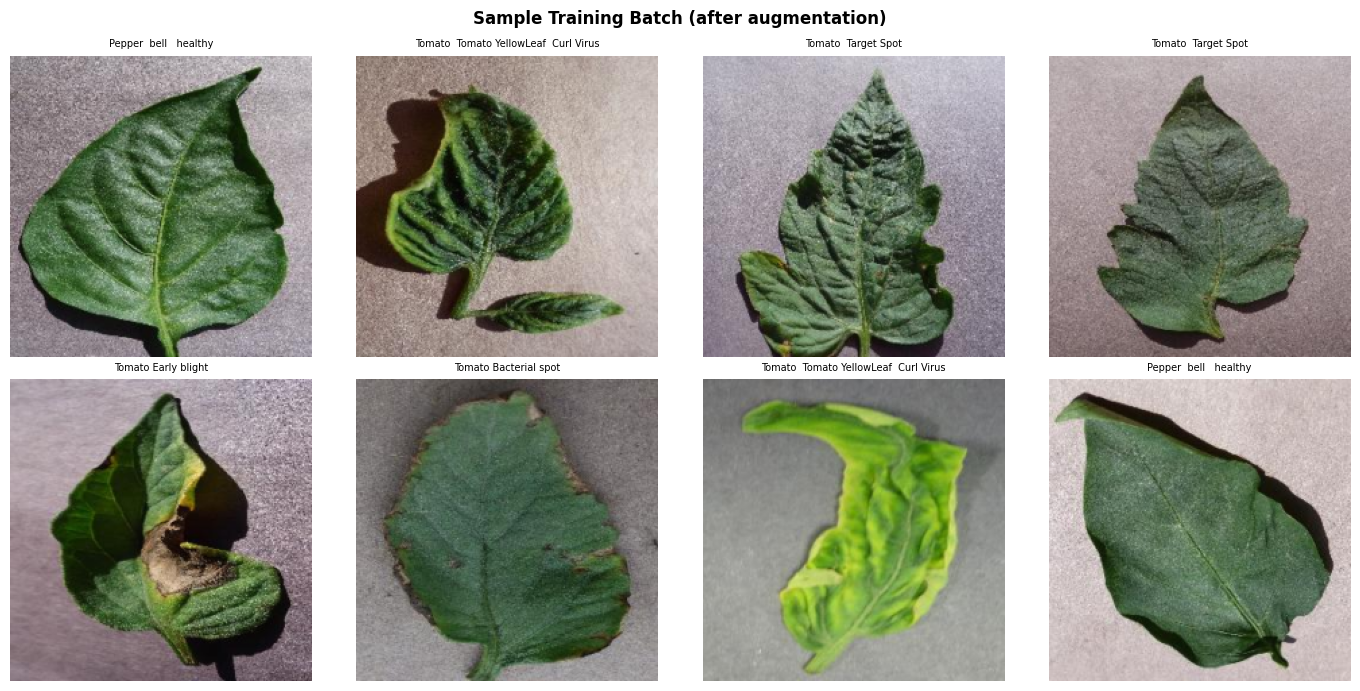

Saved sample_batch.png


In [49]:
# Denormalize for display
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Show 8 images from the batch
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}

for i, ax in enumerate(axes.flatten()):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(idx_to_class[labels[i].item()].replace('_', ' '), fontsize=7)
    ax.axis('off')

plt.suptitle('Sample Training Batch (after augmentation)', fontweight='bold')
plt.tight_layout()
plt.savefig('sample_batch.png', dpi=150)
plt.show()

print("Saved sample_batch.png")

In [50]:
dataset_code = '''from pathlib import Path
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def get_dataloaders(data_dir, batch_size=32):
    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)

    total      = len(full_dataset)
    train_size = int(0.8 * total)
    val_size   = int(0.1 * total)
    test_size  = total - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    val_dataset.dataset.transform  = val_transforms
    test_dataset.dataset.transform = val_transforms

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader, full_dataset.classes
'''

with open('../src/dataset.py', 'w') as f:
    f.write(dataset_code)

print("Saved ../src/dataset.py")

Saved ../src/dataset.py
